# Lab 5: MNIST CNN Classifier

**COMP 395 — Deep Learning**
**Due: March 20, 2026**
**Individual assignment**

---

## Overview

In this lab you will train convolutional neural networks to classify handwritten digits from the MNIST dataset. You will start by training an MLP baseline, then build and train the `SimpleCNN` from our in-class lab, and finally experiment with architectural modifications — all tracked with MLflow.

This lab is intentionally less scaffolded than previous labs. You have done every individual piece before (data loading, training loops, evaluation, MLflow logging). The challenge here is putting them together independently in a new context.

## Setup

You will need the following libraries. Refer to your earlier labs if you don't remember how any of these work.

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import mlflow
import mlflow.pytorch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Part 1: Data Loading and Preprocessing

We load the MNIST dataset using `torchvision`. The key steps:

- `transforms.ToTensor()` converts PIL images to PyTorch tensors and scales pixel values from [0, 255] to [0, 1]. It also rearranges the shape to `(C, H, W)` — the format `nn.Conv2d` expects.
- `transforms.Normalize((0.1307,), (0.3081,))` standardizes using the MNIST dataset's global mean and standard deviation. This centers the data around zero, which helps training converge faster.
- We create separate `DataLoader`s for training and testing. The training loader shuffles; the test loader does not (shuffling the test set would change nothing about evaluation, but ordered data is easier to inspect).

In [52]:
# Preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),                        # PIL -> tensor, scales to [0, 1], shape (1, 28, 28)
    transforms.Normalize((0.1307,), (0.3081,)),   # standardize with MNIST mean/std
])

# Download and load MNIST
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

# Create DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Batch size:       {batch_size}")

Training samples: 60000
Test samples:     10000
Batch size:       64


### 1.1 Understanding the DataLoader

Before you start training, take a moment to understand what the `DataLoader` is actually giving you. A `DataLoader` wraps a dataset and provides:

- **Batching:** instead of feeding one image at a time, it groups images into batches (e.g., 64 at once). This is more efficient for the GPU and provides a more stable gradient estimate.
- **Shuffling:** randomizes the order each epoch so the model doesn't memorize the sequence.
- **An iterator:** you loop over it with `for images, labels in dataloader:` and it yields one batch at a time.

Run the cell below to inspect what comes out of the DataLoader.

In [53]:
# Grab one batch from the training DataLoader
images, labels = next(iter(train_loader))

print(f"Batch of images shape: {images.shape}")
print(f"Batch of labels shape: {labels.shape}")
print(f"Label dtype: {labels.dtype}")
print()

# Unpack the shape
N, C, H, W = images.shape
print(f"  N = {N}  (batch size — number of images in this batch)")
print(f"  C = {C}  (channels — 1 for grayscale, 3 for RGB)")
print(f"  H = {H}  (height in pixels)")
print(f"  W = {W}  (width in pixels)")
print()

# Pixel value range after your transforms
print(f"Pixel value range: [{images.min():.4f}, {images.max():.4f}]")
print(f"  (If you normalized with mean=0.1307, std=0.3081,")
print(f"   these won't be [0,1] anymore — that's expected.)")
print()

# What does one label look like?
print(f"First 10 labels in this batch: {labels[:10].tolist()}")
print(f"  (These are integers 0-9, one per image.)")

Batch of images shape: torch.Size([64, 1, 28, 28])
Batch of labels shape: torch.Size([64])
Label dtype: torch.int64

  N = 64  (batch size — number of images in this batch)
  C = 1  (channels — 1 for grayscale, 3 for RGB)
  H = 28  (height in pixels)
  W = 28  (width in pixels)

Pixel value range: [-0.4242, 2.8215]
  (If you normalized with mean=0.1307, std=0.3081,
   these won't be [0,1] anymore — that's expected.)

First 10 labels in this batch: [2, 1, 1, 5, 5, 9, 5, 3, 8, 8]
  (These are integers 0-9, one per image.)


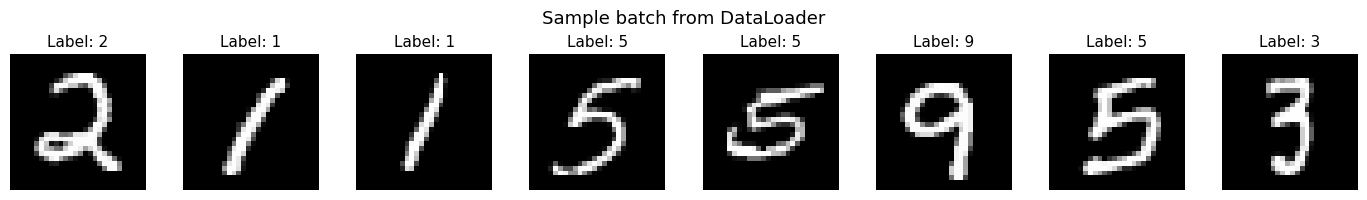

In [54]:
# Visualize a few images from the batch to confirm everything looks right
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i in range(8):
    # images[i] has shape (C, H, W) — squeeze out the channel dim for grayscale
    img = images[i].squeeze().numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}", fontsize=11)
    axes[i].axis('off')
plt.suptitle("Sample batch from DataLoader", fontsize=13)
plt.tight_layout()
plt.show()

### 1.2 How the DataLoader fits into training

When you write a training loop, the DataLoader is what you iterate over:

```python
for epoch in range(num_epochs):
    for images, labels in train_loader:   # <-- one batch at a time
        outputs = model(images)            # forward pass on the batch
        loss = criterion(outputs, labels)  # compute loss for the batch
        ...
```

Each call to the loop yields a fresh batch. After you've gone through every batch once, that's one **epoch**. The DataLoader handles all the bookkeeping of which samples have been used, reshuffling, etc.

**Checkpoint:** Before moving on, make sure you can answer:

1. What is the shape of a single batch of images from your DataLoader?
2. What do the labels look like — are they integers or one-hot vectors?
3. How many batches are in one epoch? (Hint: `len(train_loader)`)

---

In [55]:
# How many batches per epoch?
print(f"Training batches per epoch: {len(train_loader)}")
print(f"  = {len(train_loader.dataset)} images / {train_loader.batch_size} per batch")

Training batches per epoch: 938
  = 60000 images / 64 per batch


## Part 2: MLP Baseline

Before building a CNN, we train a simple MLP on MNIST as a baseline. This gives you a point of comparison and — just as importantly — establishes the training loop and evaluation code that you'll reuse for every experiment that follows.

Study this section carefully. For Parts 3–5, you'll swap in a different model but keep everything else.

### 2.1 Model Definition

The MLP flattens each 28×28 image into a 784-dimensional vector and passes it through fully connected layers. This throws away all spatial structure — the model has no idea that pixel (0,0) is next to pixel (0,1). That's exactly the limitation CNNs will fix.

In [56]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()              # (N, 1, 28, 28) -> (N, 784)
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)                         # raw logits — no softmax here
        return x

mlp_model = MLP()

# Count parameters
total_params = sum(p.numel() for p in mlp_model.parameters())
print(f"MLP parameters: {total_params:,}")
print(f"  fc1: 784 × 256 + 256 = {784*256 + 256:,}")
print(f"  fc2: 256 × 128 + 128 = {256*128 + 128:,}")
print(f"  fc3: 128 × 10  + 10  = {128*10 + 10:,}")

MLP parameters: 235,146
  fc1: 784 × 256 + 256 = 200,960
  fc2: 256 × 128 + 128 = 32,896
  fc3: 128 × 10  + 10  = 1,290


### 2.2 Training Loop

This is the same train loop pattern from Lab 4. We use cross-entropy loss (which expects raw logits, not softmax outputs) and Adam optimizer.

We also define an `evaluate` function that we'll reuse for every experiment.

In [57]:
def evaluate(model, data_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # --- NEW: Collect these for the Confusion Matrix ---
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    accuracy = 100 * correct / total
    # This now returns THREE things instead of one
    return accuracy, all_preds, all_labels

In [58]:
# 1. Define the device (Crucial for WSL + GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_model.to(device)

# Training setup
num_epochs = 10
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=learning_rate)

# Training loop
mlp_loss_history = []

for epoch in range(num_epochs):
    mlp_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        # --- FIX: Move data to the same device as the model ---
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = mlp_model(images)
        loss = criterion(outputs, labels)

        # Backward pass and update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    mlp_loss_history.append(avg_loss)

    # Check accuracy every few epochs
    if (epoch + 1) % 2 == 0 or epoch == 0:
        # This now works because images are moved to device inside evaluate()
        acc, _, _ = evaluate(mlp_model, test_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f}  Test Acc: {acc:.2f}%")

Epoch [1/10]  Loss: 0.2287  Test Acc: 96.48%
Epoch [2/10]  Loss: 0.0928  Test Acc: 96.58%
Epoch [4/10]  Loss: 0.0496  Test Acc: 97.35%
Epoch [6/10]  Loss: 0.0331  Test Acc: 97.61%
Epoch [8/10]  Loss: 0.0220  Test Acc: 97.75%
Epoch [10/10]  Loss: 0.0211  Test Acc: 97.56%


### 2.3 Evaluation

MLP final test accuracy: 97.56%


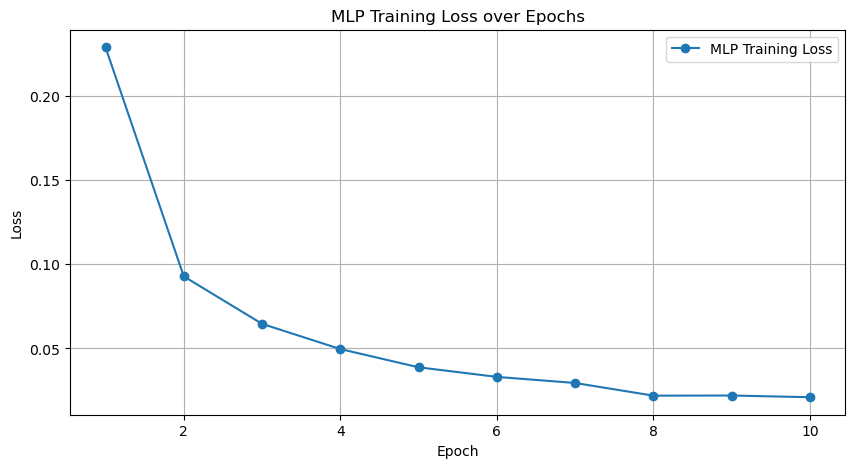

In [60]:
# 1. Unpack all three values (Accuracy, Predictions, Labels)
mlp_accuracy, mlp_preds, mlp_labels = evaluate(mlp_model, test_loader)

# 2. Now printing works because mlp_accuracy is just a single number again
print(f"MLP final test accuracy: {mlp_accuracy:.2f}%")

# 3. Plot training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), mlp_loss_history, label='MLP Training Loss', marker='o')
plt.title('MLP Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

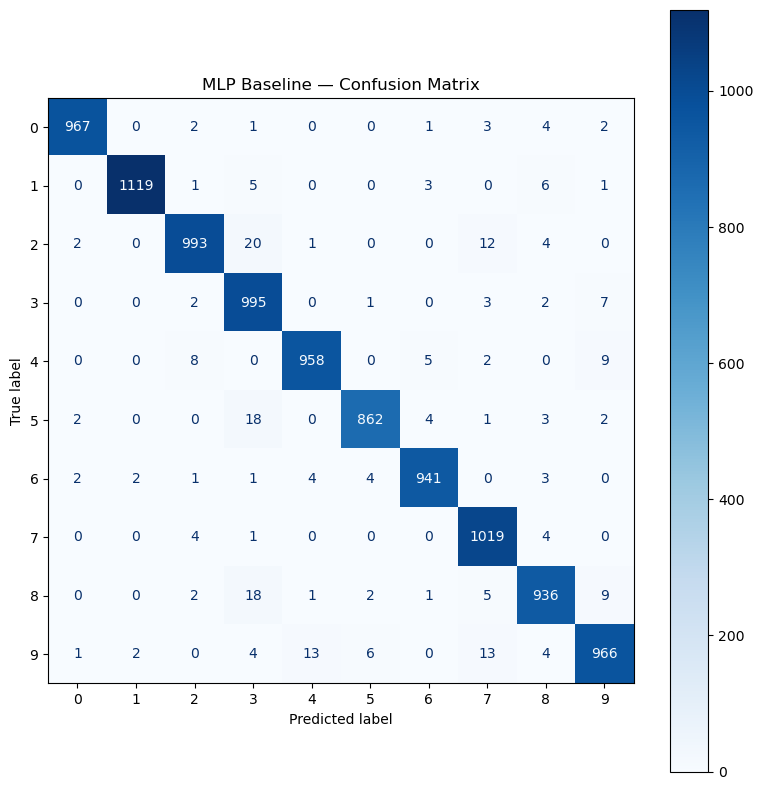

Saved mlp_confusion_matrix.png


In [61]:
# Confusion matrix
cm = confusion_matrix(mlp_labels, mlp_preds)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title("MLP Baseline — Confusion Matrix")
plt.tight_layout()
plt.show()

# Save for MLflow logging later
fig.savefig("mlp_confusion_matrix.png", dpi=100, bbox_inches='tight')
print("Saved mlp_confusion_matrix.png")

### 2.4 MLflow Logging (Optional — Do This Now or in Part 6)

The cell below logs everything for this run. You can run it now or come back during Part 6. Either way, you'll need to do this for every experiment, so it's worth getting it working here first.

In [62]:
import mlflow
import mlflow.pytorch

# 1. Reset any existing runs to prevent "Active run already exists" error
mlflow.end_run()

# 2. Set the Experiment Name
mlflow.set_experiment("Lab5-MNIST")

with mlflow.start_run(run_name="MLP-baseline"):
    # --- LOG PARAMETERS ---
    # We pull batch_size directly from the train_loader to be safe
    current_batch_size = train_loader.batch_size
    
    mlflow.log_param("model_type", "MLP")
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("batch_size", current_batch_size)
    mlflow.log_param("num_epochs", num_epochs)
    mlflow.log_param("optimizer", "Adam")

    # --- LOG TAG ---
    mlflow.set_tag("architecture", "MLP-784-256-128-10")

    # --- LOG METRICS ---
    # Log training loss for each epoch recorded in your history
    for epoch_idx, loss_val in enumerate(mlp_loss_history):
        mlflow.log_metric("train_loss", loss_val, step=epoch_idx + 1)
    
    # Log the final accuracy percentage
    mlflow.log_metric("test_accuracy", mlp_accuracy)

    # --- LOG ARTIFACTS ---
    # This logs the .png file you saved in the previous step
    # Make sure fig.savefig("mlp_confusion_matrix.png") was run first!
    try:
        mlflow.log_artifact("mlp_confusion_matrix.png")
    except Exception as e:
        print(f"Warning: Could not log artifact. Error: {e}")

    # --- LOG MODEL ---
    # This saves the actual model weights so you can load them later
    mlflow.pytorch.log_model(mlp_model, "mlp_baseline_model")

    print(f"Successfully logged MLP baseline to MLflow!")
    print(f"Final logged accuracy: {mlp_accuracy:.2f}%")

2026/03/23 21:40:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 21:40:11 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Successfully logged MLP baseline to MLflow!
Final logged accuracy: 97.56%


---

### What to reuse for Parts 3–5

When you build your CNN and run experiments, you should reuse:

- **`evaluate()`** — works with any model, no changes needed.
- **The training loop** — the only thing that changes is which model and optimizer you pass in. Consider wrapping it in a function:

python
def train_model(model, train_loader, num_epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_history = []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        loss_history.append(running_loss / len(train_loader))
    return loss_history


- **The confusion matrix code** — just change the filename and title.
- **The MLflow logging pattern** — change the run name, tag, and parameters.

---

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_model(model, train_loader, num_epochs=10, lr=0.001):
    # Setup device (WSL GPU support)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_history = []
    
    print(f"Starting training on {device}...")
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            # Move data to GPU/CPU
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        epoch_loss = running_loss / len(train_loader)
        loss_history.append(epoch_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")
        
    return loss_history

## Part 3: CNN Classifier

Now build and train a CNN on the same data. You can use the `SimpleCNN` from the Day 2 in-class lab, or write your own architecture.

**Requirements:**

- At least two convolutional layers with ReLU and max pooling.
- A fully connected classification head that outputs 10 classes.
- Train using cross-entropy loss and an appropriate optimizer.
- Log the run to MLflow.
- Record the final test accuracy and compare to your MLP baseline.

The only thing that changes from Part 2 is the model definition. Your data loading, training loop, and evaluation code should be reusable. If they aren't, refactor them into a function.

In [64]:
# Define your CNN model

import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # First Convolutional Layer: 1 input channel (Grayscale), 32 filters, 3x3 kernel
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        # Second Convolutional Layer: 32 input, 64 filters, 3x3 kernel
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # Max Pooling layer to reduce spatial dimensions by half
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully Connected Head
        # After two 2x2 pools, a 28x28 image becomes 7x7. 
        # 64 channels * 7 * 7 = 3136 features
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10) # 10 classes for output

    def forward(self, x):
        # Layer 1: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))
        # Layer 2: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))
        
        # Flatten the tensor for the fully connected layers
        x = x.view(-1, 64 * 7 * 7)
        
        # Classification Head
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the model
model = SimpleCNN()


In [65]:
# 1. Instantiate the model
model = SimpleCNN()

# 2. START THE MLFLOW RUN
import mlflow
import mlflow.pytorch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

mlflow.end_run() 
mlflow.set_experiment("MNIST_Classification")

with mlflow.start_run(run_name="Simple_CNN_Part3"):
    # --- Setup ---
    lr = 0.001
    epochs = 10
    
    # --- Log Parameters (Before Training) ---
    mlflow.log_param("model_type", "CNN")
    mlflow.log_param("learning_rate", lr)
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("batch_size", train_loader.batch_size)
    mlflow.set_tag("architecture", "SimpleCNN")

    # --- THE TRAINING (The "Work") ---
    # This runs the print statements inside your train_model function
    loss_history = train_model(model, train_loader, num_epochs=epochs, lr=lr)

    # --- THE EVALUATION ---
    # Get the numbers and the lists for the Confusion Matrix
    test_acc, y_pred, y_true = evaluate(model, test_loader) 

    # --- LOG METRICS & ARTIFACTS (After Training is Done) ---
    for i, loss in enumerate(loss_history):
        mlflow.log_metric("train_loss", loss, step=i + 1)
    
    mlflow.log_metric("test_accuracy", test_acc)

    # Confusion Matrix Logic
    fig, ax = plt.subplots(figsize=(8, 8))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title("SimpleCNN Confusion Matrix")
    
    cnn_cm_path = "simple_cnn_confusion_matrix.png"
    plt.savefig(cnn_cm_path)
    mlflow.log_artifact(cnn_cm_path) # <--- This is the key Part 6 step
    plt.close(fig)

    mlflow.pytorch.log_model(model, "cnn_model")
    
    # Final Summary Prints
    print(f"DONE: CNN Test Accuracy is {test_acc:.2f}%")
    if 'mlp_accuracy' in locals():
        print(f"Improvement over MLP: {test_acc - mlp_accuracy:+.2f}%")

Starting training on cuda...
Epoch [1/10], Loss: 0.1368
Epoch [2/10], Loss: 0.0425
Epoch [3/10], Loss: 0.0286
Epoch [4/10], Loss: 0.0215
Epoch [5/10], Loss: 0.0148
Epoch [6/10], Loss: 0.0125
Epoch [7/10], Loss: 0.0117
Epoch [8/10], Loss: 0.0096
Epoch [9/10], Loss: 0.0071
Epoch [10/10], Loss: 0.0075


2026/03/23 21:43:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 21:43:01 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


DONE: CNN Test Accuracy is 99.02%
Improvement over MLP: +1.46%


## Part 4: Required Experiments — Kernel Size and Filter Counts

Modify the CNN architecture in at least **two** of the following ways. Each should be a separate MLflow run with a descriptive tag so you can compare them later.

**Choose at least two:**

- Change the convolutional kernel size (e.g., from 3×3 to 5×5).
- Change the number of filters (e.g., from 16→32 to 32→64, or reduce to 8→16).
- Try both changes together.

**Important:** if you change the kernel size or the number of pooling layers, the spatial dimensions at the flatten step will change. You need to recompute the input size for your first fully connected layer. Use the shape-tracing technique from the Day 2 lab.

For each experiment, record: what you changed, what you expected to happen, and what actually happened.

In [66]:
import mlflow
mlflow.end_run()

In [67]:
import mlflow
import mlflow.pytorch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Cleanup and Setup
mlflow.end_run()
mlflow.set_experiment("MNIST_Experiments") # Or your chosen experiment name

with mlflow.start_run(run_name="CNN_Kernel_5x5"):
    # --- Settings ---
    k_size = 5
    lr = 0.001
    epochs = 5
    batch_size = train_loader.batch_size
    
    # --- Architecture ---
    model = CNN_KernelExp(k_size=k_size)
    
    # --- 1. LOG PARAMETERS (Requirement 6.1) ---
    mlflow.log_param("kernel_size", k_size)
    mlflow.log_param("learning_rate", lr)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("num_epochs", epochs)
    mlflow.log_param("optimizer", "Adam")
    
    # --- 2. LOG TAG (Requirement 6.2) ---
    mlflow.set_tag("architecture", "CNN-5x5kernels")

    # --- 3. TRAIN ---
    losses = train_model(model, train_loader, num_epochs=epochs, lr=lr)
    
    # --- 4. LOG METRICS (Requirement 6.3) ---
    # Log loss per epoch
    for i, loss in enumerate(losses):
        mlflow.log_metric("train_loss", loss, step=i + 1)
    
    # Final Evaluation
    acc, y_pred, y_true = evaluate(model, test_loader)
    mlflow.log_metric("test_accuracy", acc)

    # --- 5. LOG ARTIFACT: CONFUSION MATRIX (Requirement 6.4) ---
    fig, ax = plt.subplots(figsize=(8, 8))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(f"Confusion Matrix: CNN Kernel {k_size}x{k_size}")
    
    # Save the file locally first
    cm_filename = "cnn_5x5_confusion_matrix.png"
    plt.savefig(cm_filename)
    
    # Log the file to MLflow
    mlflow.log_artifact(cm_filename)
    plt.close(fig) # Keeps notebook clean

    # 6. Log the Model (Best practice)
    mlflow.pytorch.log_model(model, "model")

    print(f"Experiment Complete! Logged Accuracy: {acc:.2f}%")

Tracing: Flatten size for Kernel 5 is 3136
Starting training on cuda...
Epoch [1/5], Loss: 0.1242
Epoch [2/5], Loss: 0.0390
Epoch [3/5], Loss: 0.0257
Epoch [4/5], Loss: 0.0199
Epoch [5/5], Loss: 0.0163


2026/03/23 21:45:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 21:45:07 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Experiment Complete! Logged Accuracy: 99.11%


In [68]:
import mlflow
import mlflow.pytorch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Cleanup and Setup
mlflow.end_run() # Close any previous runs
mlflow.set_experiment("MNIST_Experiments")

with mlflow.start_run(run_name="CNN_Filters_64_128"):
    # --- Settings ---
    f1, f2 = 64, 128
    lr = 0.001
    epochs = 5
    batch_size = train_loader.batch_size
    
    # --- Architecture ---
    model = CNN_FilterExp(f1=f1, f2=f2)
    
    # --- 1. LOG PARAMETERS (Requirement 6.1) ---
    mlflow.log_param("filters_f1", f1)
    mlflow.log_param("filters_f2", f2)
    mlflow.log_param("learning_rate", lr)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("num_epochs", epochs)
    mlflow.log_param("optimizer", "Adam")
    
    # --- 2. LOG TAG (Requirement 6.2) ---
    mlflow.set_tag("architecture", "CNN-Filters-64-128")

    # --- 3. TRAIN ---
    # Using your train_model function
    losses = train_model(model, train_loader, num_epochs=epochs, lr=lr)
    
    # --- 4. LOG METRICS (Requirement 6.3) ---
    # Log loss for every epoch
    for i, loss in enumerate(losses):
        mlflow.log_metric("train_loss", loss, step=i + 1)
    
    # Final Evaluation (Unpacking all 3 values)
    acc, y_pred, y_true = evaluate(model, test_loader)
    mlflow.log_metric("test_accuracy", acc)

    # --- 5. LOG ARTIFACT: CONFUSION MATRIX (Requirement 6.4) ---
    fig, ax = plt.subplots(figsize=(8, 8))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(f"Confusion Matrix: CNN Filters {f1}/{f2}")
    
    # Save the file locally
    cm_filename = "cnn_filters_64_128_cm.png"
    plt.savefig(cm_filename)
    
    # Log the file to MLflow
    mlflow.log_artifact(cm_filename)
    plt.close(fig)

    # 6. Log the Model
    mlflow.pytorch.log_model(model, "model")

    print(f"Experiment 2 Complete! Logged Accuracy: {acc:.2f}%")

Tracing: Flatten size for Filters 64/128 is 6272
Starting training on cuda...
Epoch [1/5], Loss: 0.1164
Epoch [2/5], Loss: 0.0392
Epoch [3/5], Loss: 0.0260
Epoch [4/5], Loss: 0.0178
Epoch [5/5], Loss: 0.0150


2026/03/23 21:47:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 21:47:30 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Experiment 2 Complete! Logged Accuracy: 98.98%


## Part 5: Open Exploration

Try at least **one** additional modification beyond Part 4. Some ideas:

- Add dropout (`nn.Dropout` or `nn.Dropout2d`).
- Add batch normalization (`nn.BatchNorm2d`).
- Add a third convolutional block.
- Try a different optimizer (e.g., SGD with momentum vs. Adam).
- Experiment with learning rate schedules.
- Add data augmentation (random rotations, slight shifts) via `transforms`.
- Try a much deeper or much shallower architecture.

Log each experiment to MLflow. In your writeup, explain what you tried, what you expected to happen, and what actually happened.

In [69]:
import mlflow
import mlflow.pytorch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Cleanup and Setup
mlflow.end_run() 
mlflow.set_experiment("MNIST_Experiments") # Keeps all CNN experiments together

with mlflow.start_run(run_name="CNN_With_Batch_Norm"):
    # --- 1. SETTINGS & HYPERPARAMETERS ---
    model_bn = CNN_BatchNorm()
    lr = 0.001
    epochs = 5
    batch_size = train_loader.batch_size
    
    # --- 2. LOG PARAMETERS (Requirement 6.1) ---
    mlflow.log_param("model_type", "CNN")
    mlflow.log_param("learning_rate", lr)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("num_epochs", epochs)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("use_batch_norm", True)
    
    # --- 3. LOG TAG (Requirement 6.2) ---
    mlflow.set_tag("architecture", "CNN-BatchNorm-OpenExplore")

    # --- 4. TRAIN ---
    # Capturing the loss history to log it properly
    losses = train_model(model_bn, train_loader, num_epochs=epochs, lr=lr)
    
    # --- 5. LOG METRICS (Requirement 6.3) ---
    # Log training loss per epoch
    for i, loss in enumerate(losses):
        mlflow.log_metric("train_loss", loss, step=i + 1)
    
    # Final Evaluation (Unpacking accuracy, predictions, and labels)
    acc, y_pred, y_true = evaluate(model_bn, test_loader)
    mlflow.log_metric("test_accuracy", acc)

    # --- 6. LOG ARTIFACT: CONFUSION MATRIX (Requirement 6.4) ---
    fig, ax = plt.subplots(figsize=(8, 8))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title("Confusion Matrix: CNN with Batch Normalization")
    
    # Save the file locally
    cm_filename = "cnn_batchnorm_confusion_matrix.png"
    plt.savefig(cm_filename)
    
    # Upload the file to MLflow
    mlflow.log_artifact(cm_filename)
    plt.close(fig) # Keeps the notebook output clean

    # 7. LOG THE MODEL
    mlflow.pytorch.log_model(model_bn, "model")

    print(f"Open Exploration Complete! Batch Norm CNN Accuracy: {acc:.2f}%")

Starting training on cuda...
Epoch [1/5], Loss: 0.1184
Epoch [2/5], Loss: 0.0462
Epoch [3/5], Loss: 0.0350
Epoch [4/5], Loss: 0.0270
Epoch [5/5], Loss: 0.0217


2026/03/23 21:49:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 21:49:53 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Open Exploration Complete! Batch Norm CNN Accuracy: 98.61%


## Part 6: MLflow Logging

Every training run (MLP baseline, base CNN, each experiment) must be logged to MLflow. For each run, log:

- **Parameters:** learning rate, batch size, number of epochs, optimizer name.
- **Tag:** a short architecture description (e.g., `"SimpleCNN"`, `"MLP-baseline"`, `"CNN-5x5kernels"`).
- **Metrics:** training loss per epoch, test accuracy at the end of training.
- **Artifact:** a confusion matrix saved as a `.png` file.

For the confusion matrix, use `sklearn.metrics.confusion_matrix` and `ConfusionMatrixDisplay`. Save the figure with `plt.savefig()` and log it with `mlflow.log_artifact()`. Refer to your earlier labs for the MLflow logging pattern.

If you haven't already been logging as you go in Parts 2–5, go back and add MLflow logging to each run now. It's much easier to log as you train than to reconstruct runs after the fact.

## Part 7: Visualization

After training your best CNN, visualize what it has learned. Work through the **CNN Visualization Tutorial** notebook (`cnn_visualization_tutorial.ipynb`) first — it walks through every technique on a FashionMNIST model with full working code. Then come back here and adapt the code to your MNIST model.

You need to produce two visualizations:

1. **Learned conv1 filters** — display the first layer's weights as a grid of small grayscale images.
2. **Intermediate feature maps** — pass a single MNIST digit through your model layer by layer and display the feature maps after each conv layer.

The tutorial notebook has all the code you need; the only changes are your model variable name and layer names.

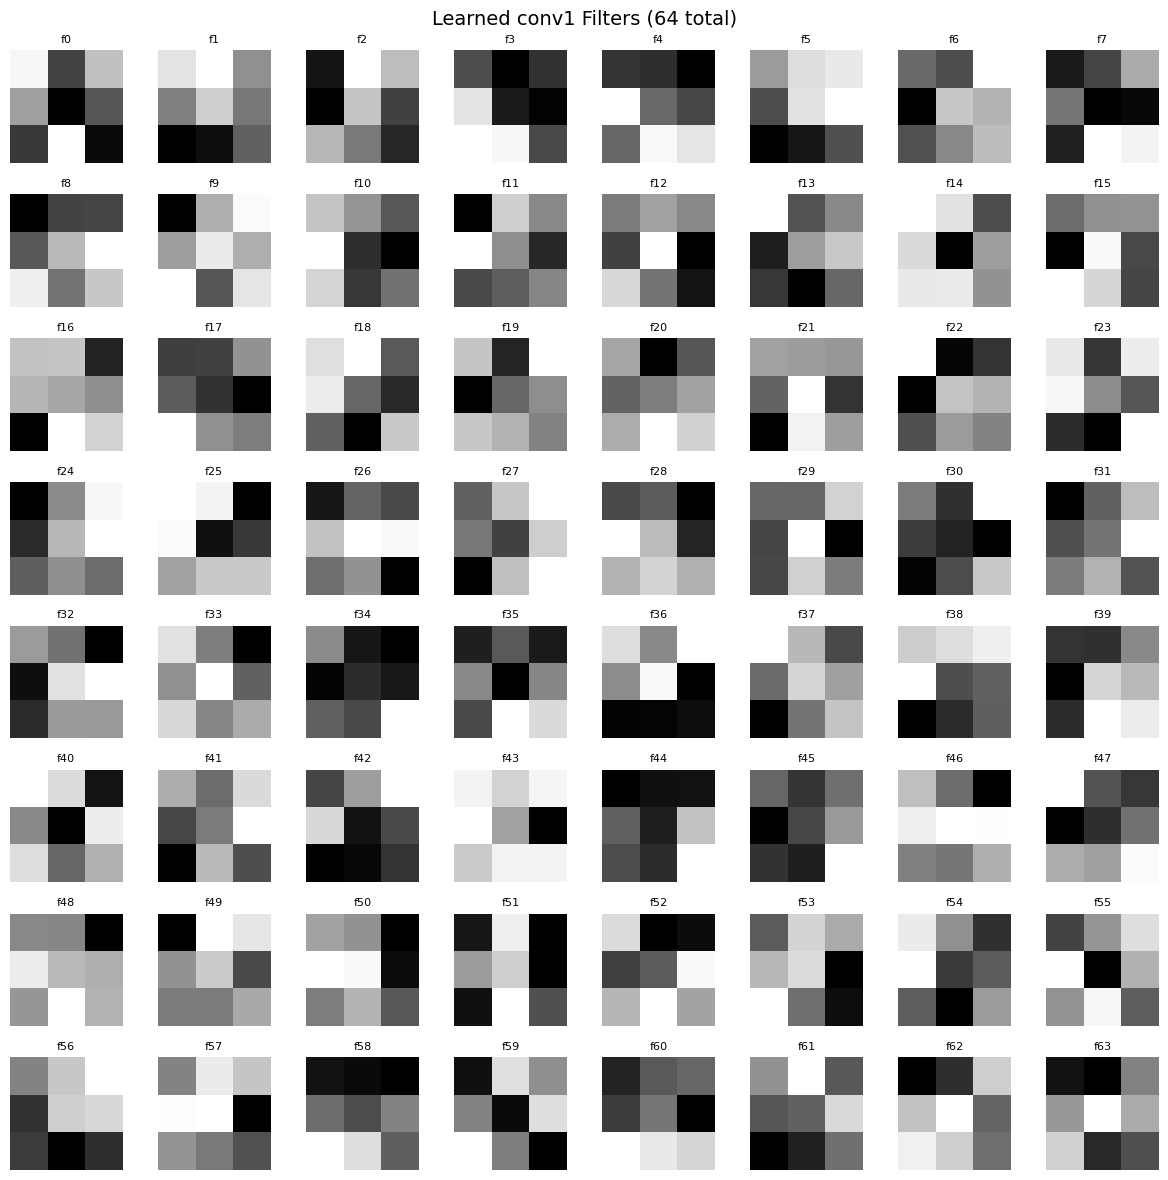

In [70]:
# Visualize learned conv1 filters
# (Adapt from Part 1 of the visualization tutorial)

# Use your best model here (e.g., model, model_bn, or mlp_model)
active_model = model # Change this to model_bn if you want to see the BatchNorm one
active_model.eval()

# 1. Extract weights
weights = active_model.conv1.weight.data.cpu()
n_filters = weights.shape[0]

# 2. Dynamic grid calculation (8 columns wide)
n_cols = 8
n_rows = n_filters // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 1.5 * n_rows))

for i, ax in enumerate(axes.flat):
    if i < n_filters:
        # Squeeze out the channel dimension for grayscale plotting
        filt = weights[i].squeeze().numpy()
        ax.imshow(filt, cmap='gray')
        ax.set_title(f"f{i}", fontsize=8)
    ax.axis('off')

plt.suptitle(f"Learned conv1 Filters ({n_filters} total)", fontsize=14)
plt.tight_layout()
plt.show()


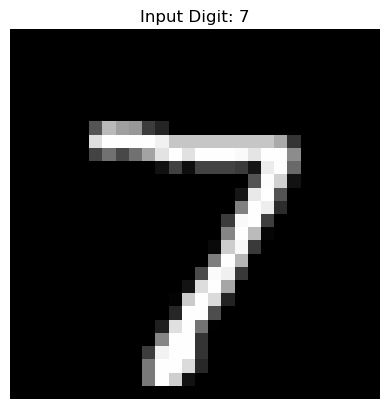

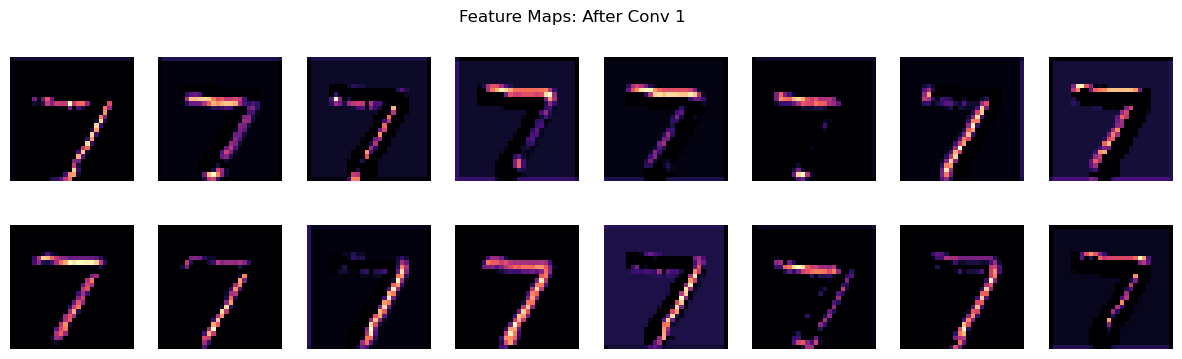

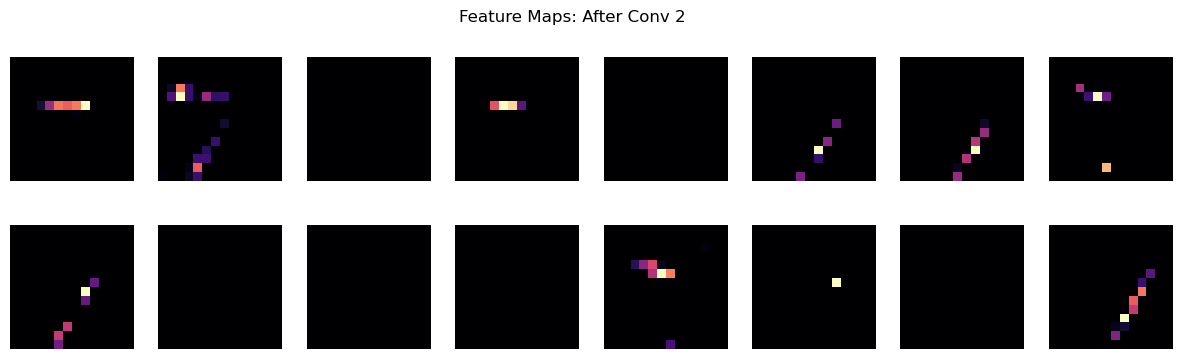

In [71]:
# Visualize intermediate feature maps on a sample MNIST digit
# (Adapt from Part 2 of the visualization tutorial)

# 1. Grab a single MNIST digit
images, labels = next(iter(test_loader))
img = images[0].to(device) # shape (1, 28, 28)
label = labels[0].item()

# 2. Prepare for manual forward pass
x = img.unsqueeze(0) # add batch dim: (1, 1, 28, 28)

with torch.no_grad():
    # Layer 1: Conv -> (BN) -> ReLU
    out1 = active_model.conv1(x)
    if hasattr(active_model, 'bn1'): out1 = active_model.bn1(out1)
    out1 = F.relu(out1)
    
    # Layer 2: Pool -> Conv -> (BN) -> ReLU
    out2 = active_model.pool(out1)
    out2 = active_model.conv2(out2)
    if hasattr(active_model, 'bn2'): out2 = active_model.bn2(out2)
    out2 = F.relu(out2)

# 3. Plotting the results
def plot_maps(tensor, title, n=16):
    maps = tensor.squeeze().cpu().numpy()
    fig, axes = plt.subplots(2, 8, figsize=(15, 4))
    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(maps[i], cmap='magma') # 'magma' or 'viridis' often shows activations better
            ax.axis('off')
    plt.suptitle(title)
    plt.show()

# Show Input
plt.imshow(img.cpu().squeeze(), cmap='gray')
plt.title(f"Input Digit: {label}")
plt.axis('off')
plt.show()

# Show Maps
plot_maps(out1, "Feature Maps: After Conv 1")
plot_maps(out2, "Feature Maps: After Conv 2")


---

## Deliverables

Submit two files:

### 1. This notebook (`.ipynb`)

Your complete, executed notebook containing all code, outputs, and results for Parts 1–7. The notebook should run top to bottom without errors.

### 2. Writeup (`.md` or `.pdf`)

A short report (1–2 pages) covering:

- **Baseline comparison:** MLP vs. base CNN — what was the accuracy difference? Why does the CNN do better (or not)?
- **Experiment summary:** A table of all your MLflow runs showing architecture, key hyperparameters, and test accuracy.
- **Analysis of experiments:** For each experiment in Parts 4 and 5, what did you change, what did you expect, and what happened? Reference your MLflow metrics.
- **Visualization discussion:** What do the learned filters look like? How do the feature maps relate to the input?
- **Reflection:** What surprised you? If you had another week, what would you try next?

---

## Grading Rubric

| Component | Points |
|-----------|--------|
| CNN classifier (working, logged) | 20 |
| Kernel size / filter count experiments (at least two, logged) | 20 |
| Open exploration (at least one, logged) | 20 |
| MLflow logging (all runs, parameters, tags, confusion matrices) | 20 |
| Visualization (learned filters + intermediate feature maps) | 20 |
| Writeup (comparison, analysis, reflection) | 50 |
| **Total** | **150** |

---

## Tips

- **Start with Part 2.** If your MLP training loop works, everything else is a model swap.
- **Reuse code.** Write a `train_and_evaluate` function that takes a model, trains it, evaluates it, and logs everything to MLflow. Then call it for each experiment. You'll thank yourself.
- **Track your shapes.** Most CNN bugs are shape mismatches. Print `x.shape` after each layer, or use the shape-tracing technique from Day 2.
- **Don't overtrain.** MNIST is a small dataset. If your model isn't converging in 5–10 epochs, something is wrong with the setup, not the number of epochs.
- **Name your MLflow runs.** Future-you will thank present-you when comparing 8 runs in the MLflow UI.